In [1]:
from simurg_plotter.manager import PlotManager, Plots
from simurg_plotter.ionospheric_pierce_point import Series

In [2]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# График Map2d

In [3]:
from pathlib import Path
from numpy.typing import NDArray
import datetime
import h5py
from dateutil import tz
TIME_FORMAT = '%Y-%m-%d %H:%M:%S.%f'
_UTC = tz.gettz('UTC')
def retrieve_data(
    file: str | Path,
    times: list[datetime.datetime] | None = None
) -> dict[datetime.datetime, NDArray]:    
    """
    Retrieves data from HDF file and put in dictionary
    Keys are datetime.datetime values are structured numpy arrays
    file - path to file
    times - times to preserve in output
    """  
    if times is None:
        times = []
    f_in = h5py.File(file, 'r')
    lats = []
    lons = []
    values = []
    data = {}
    for str_time in list(f_in['data'])[:]:
        time = datetime.datetime.strptime(str_time, TIME_FORMAT)
        time = time.replace(tzinfo=time.tzinfo or _UTC)
        if times and not time in times:
            # print(type(time))
            continue
        
        data[time] = f_in['data'][str_time][:]
    return data

In [4]:
times = [(datetime.datetime(2024, 4, 19) + datetime.timedelta(minutes=i)).replace(tzinfo=(datetime.datetime(2024, 4, 19) + datetime.timedelta(minutes=i)).tzinfo or _UTC) for i in range(30)]
data = retrieve_data("files/dtec_2_10_2024_110_50_56_N_100_110_E_b4aa.h5", times=times)

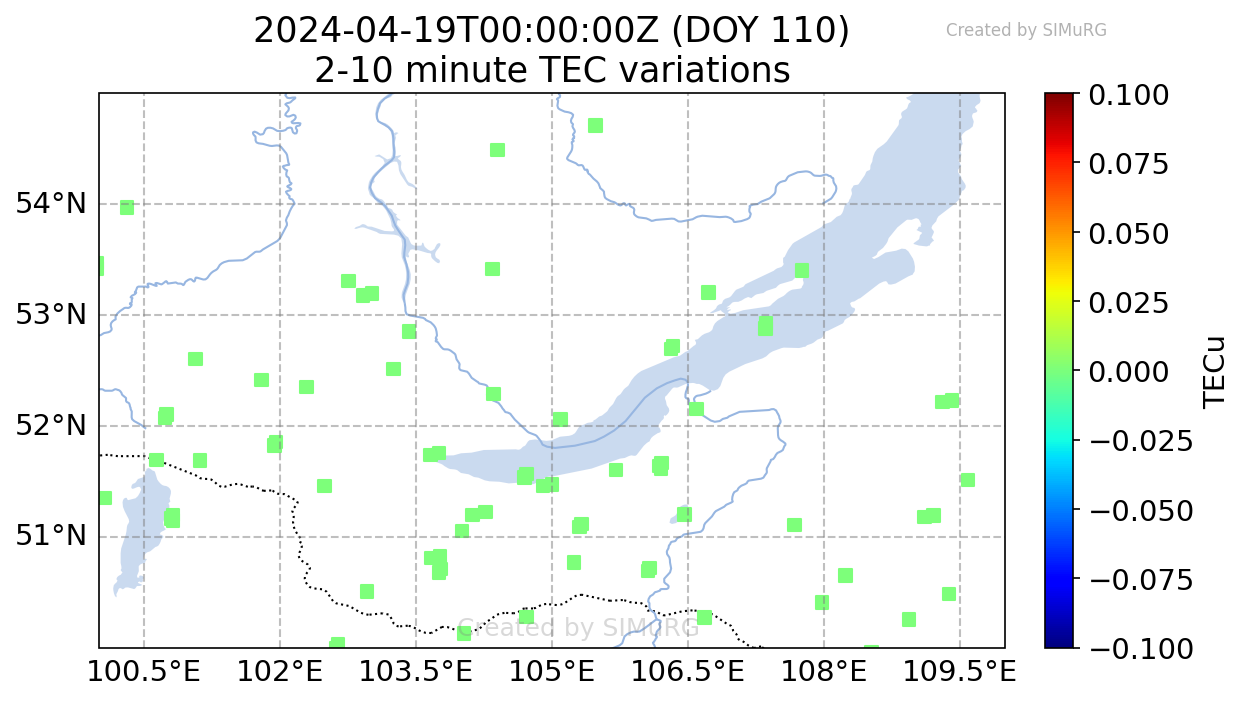

In [5]:
plotter = PlotManager(plots=[Plots.MAP2D])
plot_data = {Plots.MAP2D:(data[times[0]], {"title": "Map2D", "product_type": "dtec_2_10", "time":times[0], "save_fig":None, "polar":False, "subsolar":True, "min_lat":50, "max_lat":55, "min_lon":100, "max_lon":110})} 
plotter.draw_plots(plot_data)

# График DST

In [6]:
import numpy as np

start_date = datetime.datetime(2024, 4, 1)
time_interval = datetime.timedelta(hours=1)
timestamps = [start_date + i * time_interval for i in range(24*30)]
dst_values = np.random.uniform(low=-100, high=100, size=len(timestamps))
dst_data = np.column_stack((timestamps, dst_values))

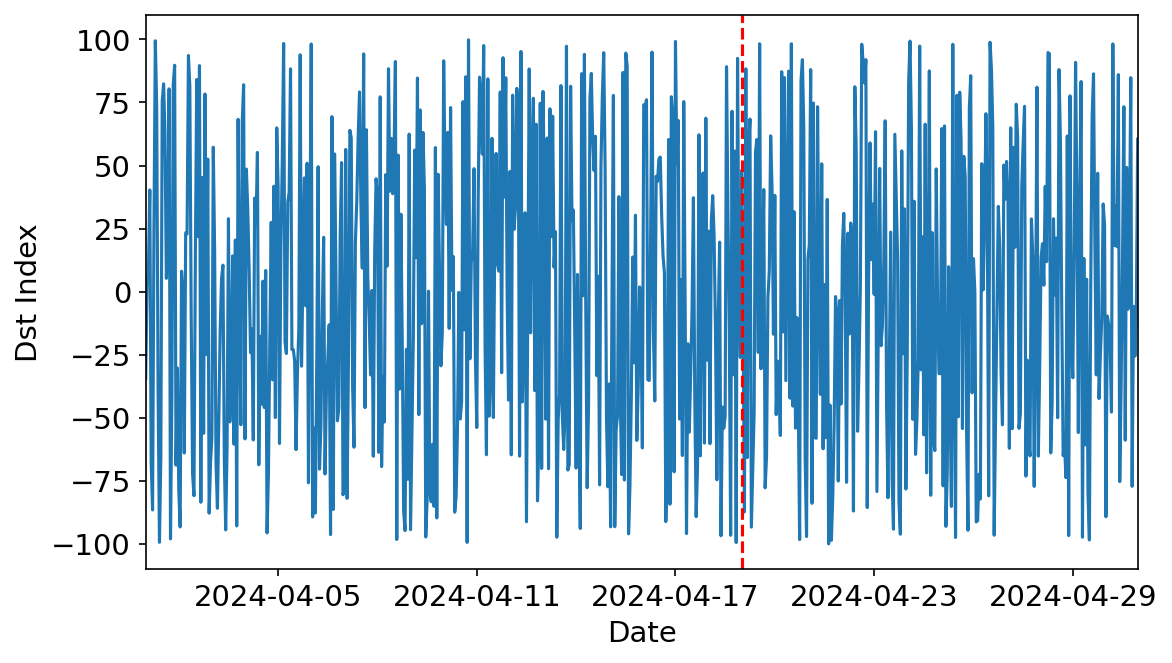

In [7]:
plotter = PlotManager([Plots.DST])
plot_data = {Plots.DST:(dst_data, {"time":times[10]})} 
plotter.draw_plots(plot_data)

# График GIM

In [8]:
import ionex
gd={}
with open('files/uqrg0010.17i') as file:
    inx = ionex.reader(file)
    for ionex_map in inx:
        gd[ionex_map.epoch.replace(tzinfo=ionex_map.epoch.tzinfo or _UTC)] = [np.reshape(ionex_map.tec, (71, 73))]

In [9]:
time = datetime.datetime(2017, 1, 1, 0, 0, 0).replace(tzinfo=datetime.datetime(2017, 1, 1, 0, 0, 0).tzinfo or _UTC)

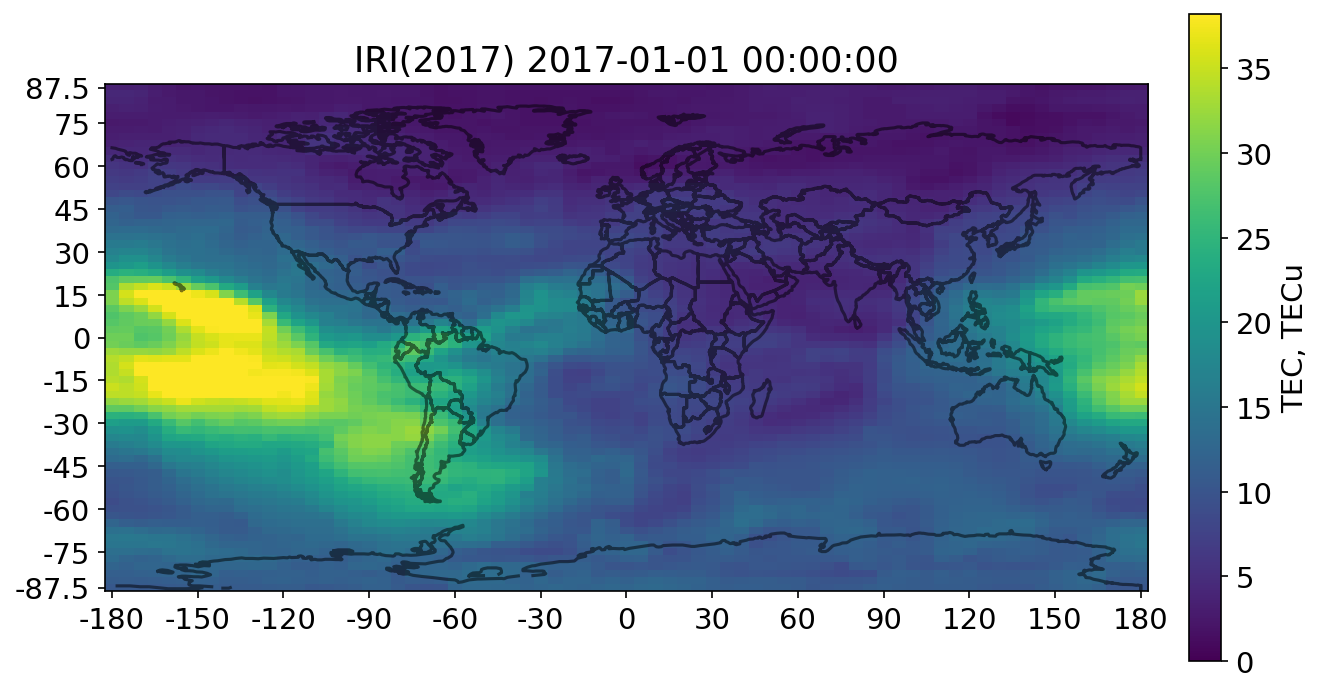

In [10]:
plotter = PlotManager([Plots.GIM])
plot_data = {Plots.GIM:(gd[time], {"title": f'IRI(2017) {time.strftime("%Y-%m-%d %H:%M:%S")}',"time":time})}
plotter.draw_plots(plot_data)

# График IPP

In [11]:
def extract_series_data(file_path: str):
    series_dict = []

    # Открытие файла HDF5
    with h5py.File(file_path, "r") as f:
        # Итерация по ключам в группе "irkj"
        for sat_key in f["irkj"].keys():
            # Извлечение данных для каждого спутника
            data = f["irkj"][sat_key]

            # Создание объекта Series из извлеченных данных
            series = Series([
                None,
                None,
                data["sip_lon"][:],
                data["sip_lat"][:],
                data["sip_larc"][:],
                data["elevation"][:],
                data["azimuth"][:],
                sat_key]
            )
            series_dict.append(series)
    return series_dict

In [12]:
ipp_data=extract_series_data("files/dtec_2_10_2021_308_7140.h5")

## IPP_MERCATOR

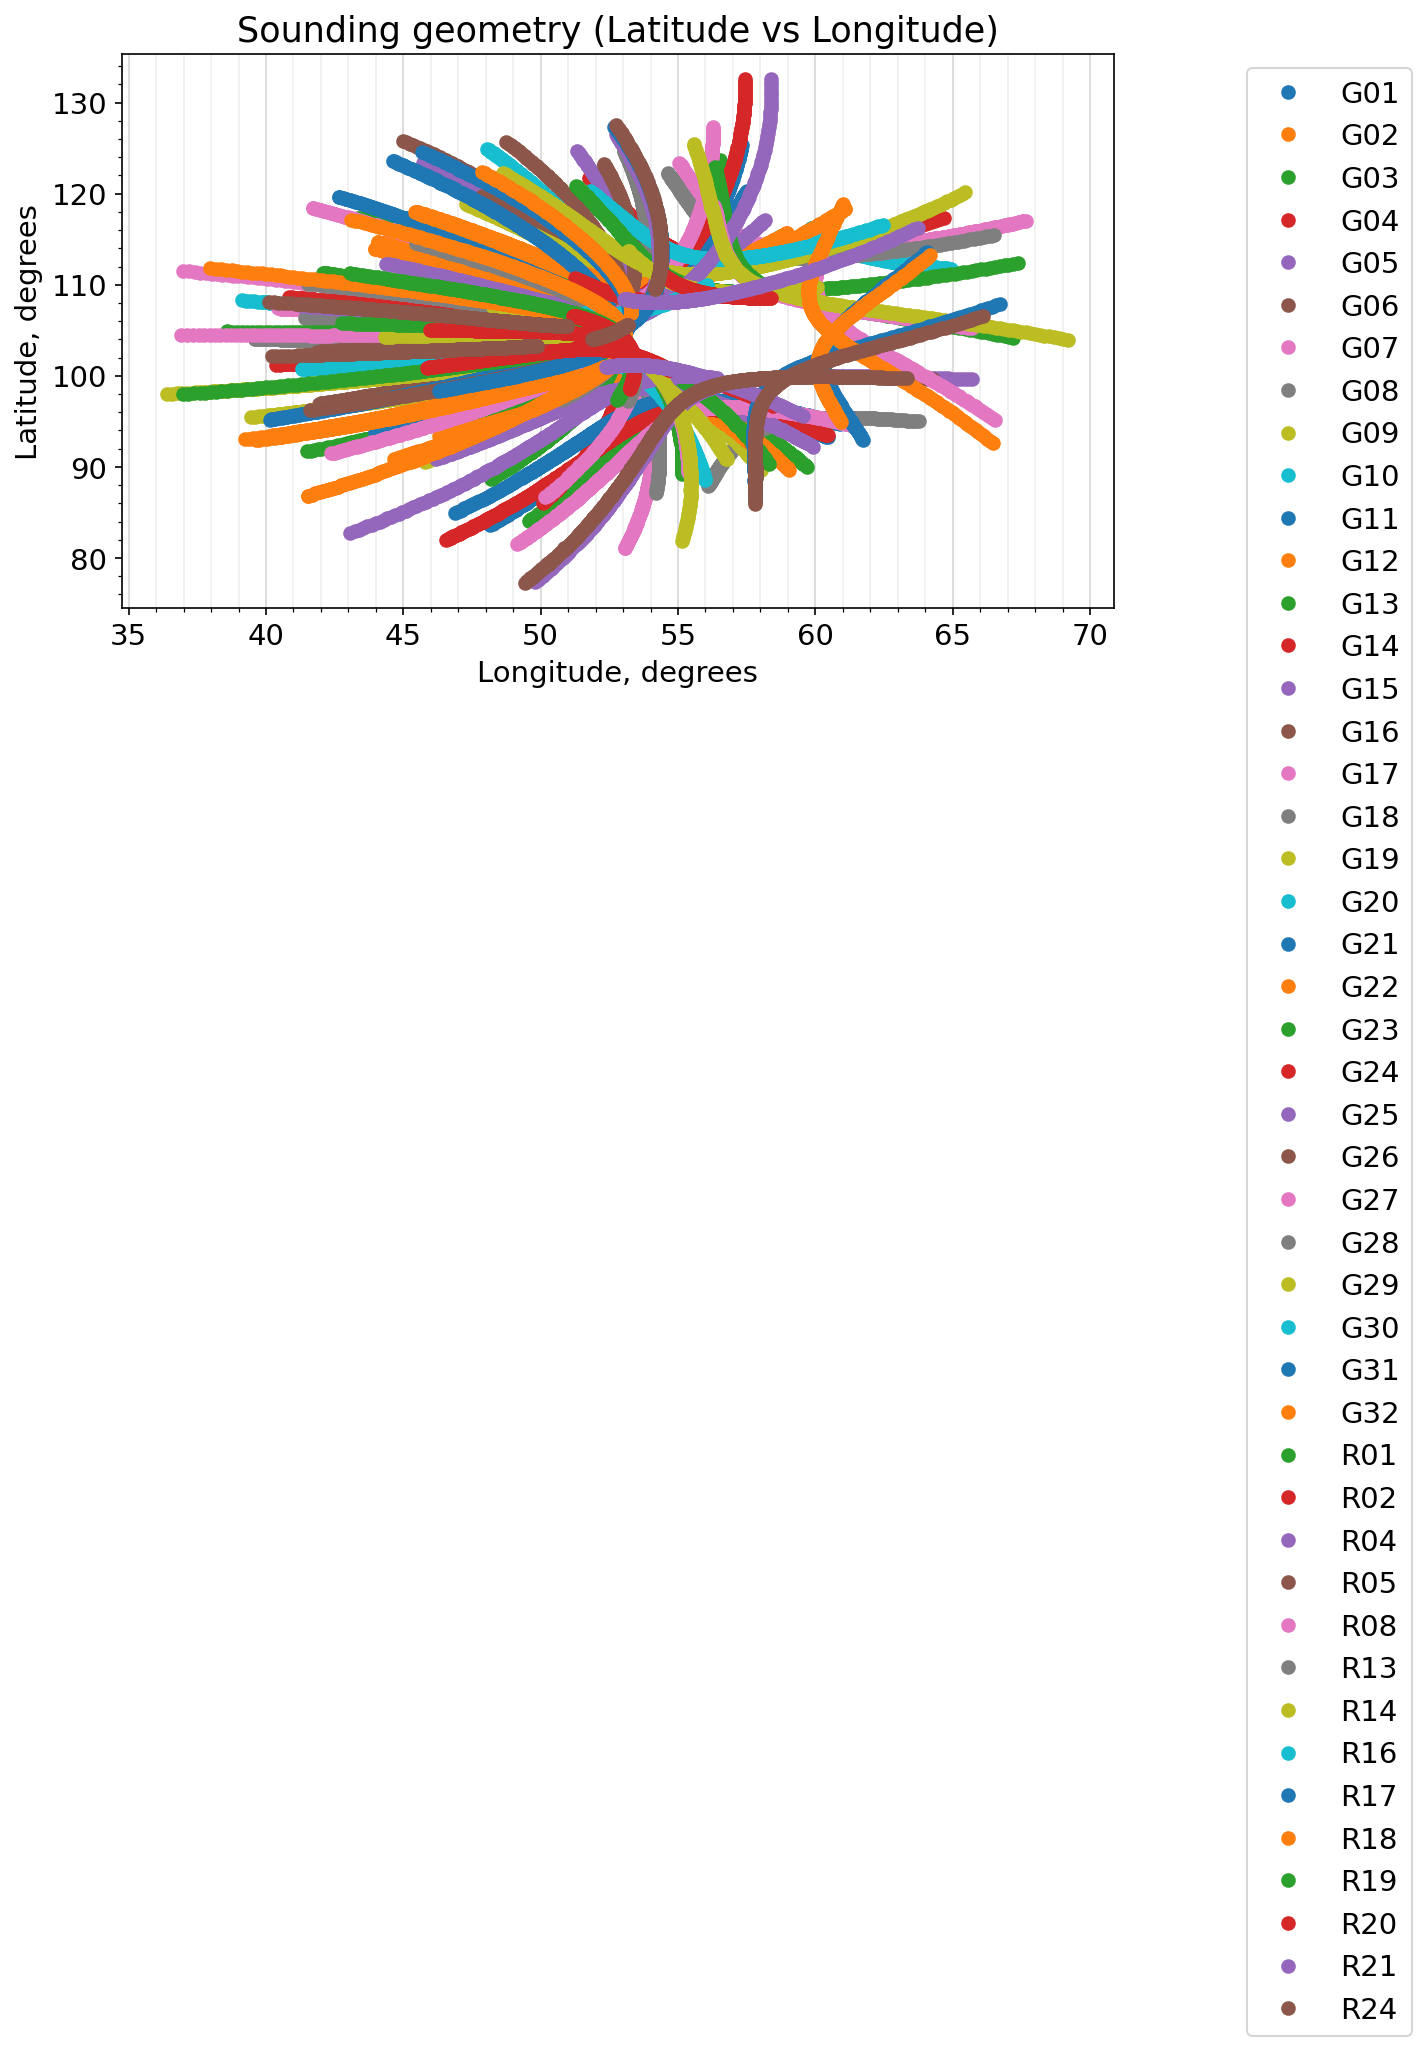

In [13]:
plotter = PlotManager([Plots.IPP_MERCATOR])
plot_data = {Plots.IPP_MERCATOR:(ipp_data, {})}
plotter.draw_plots(plot_data)

## IPP_POLAR

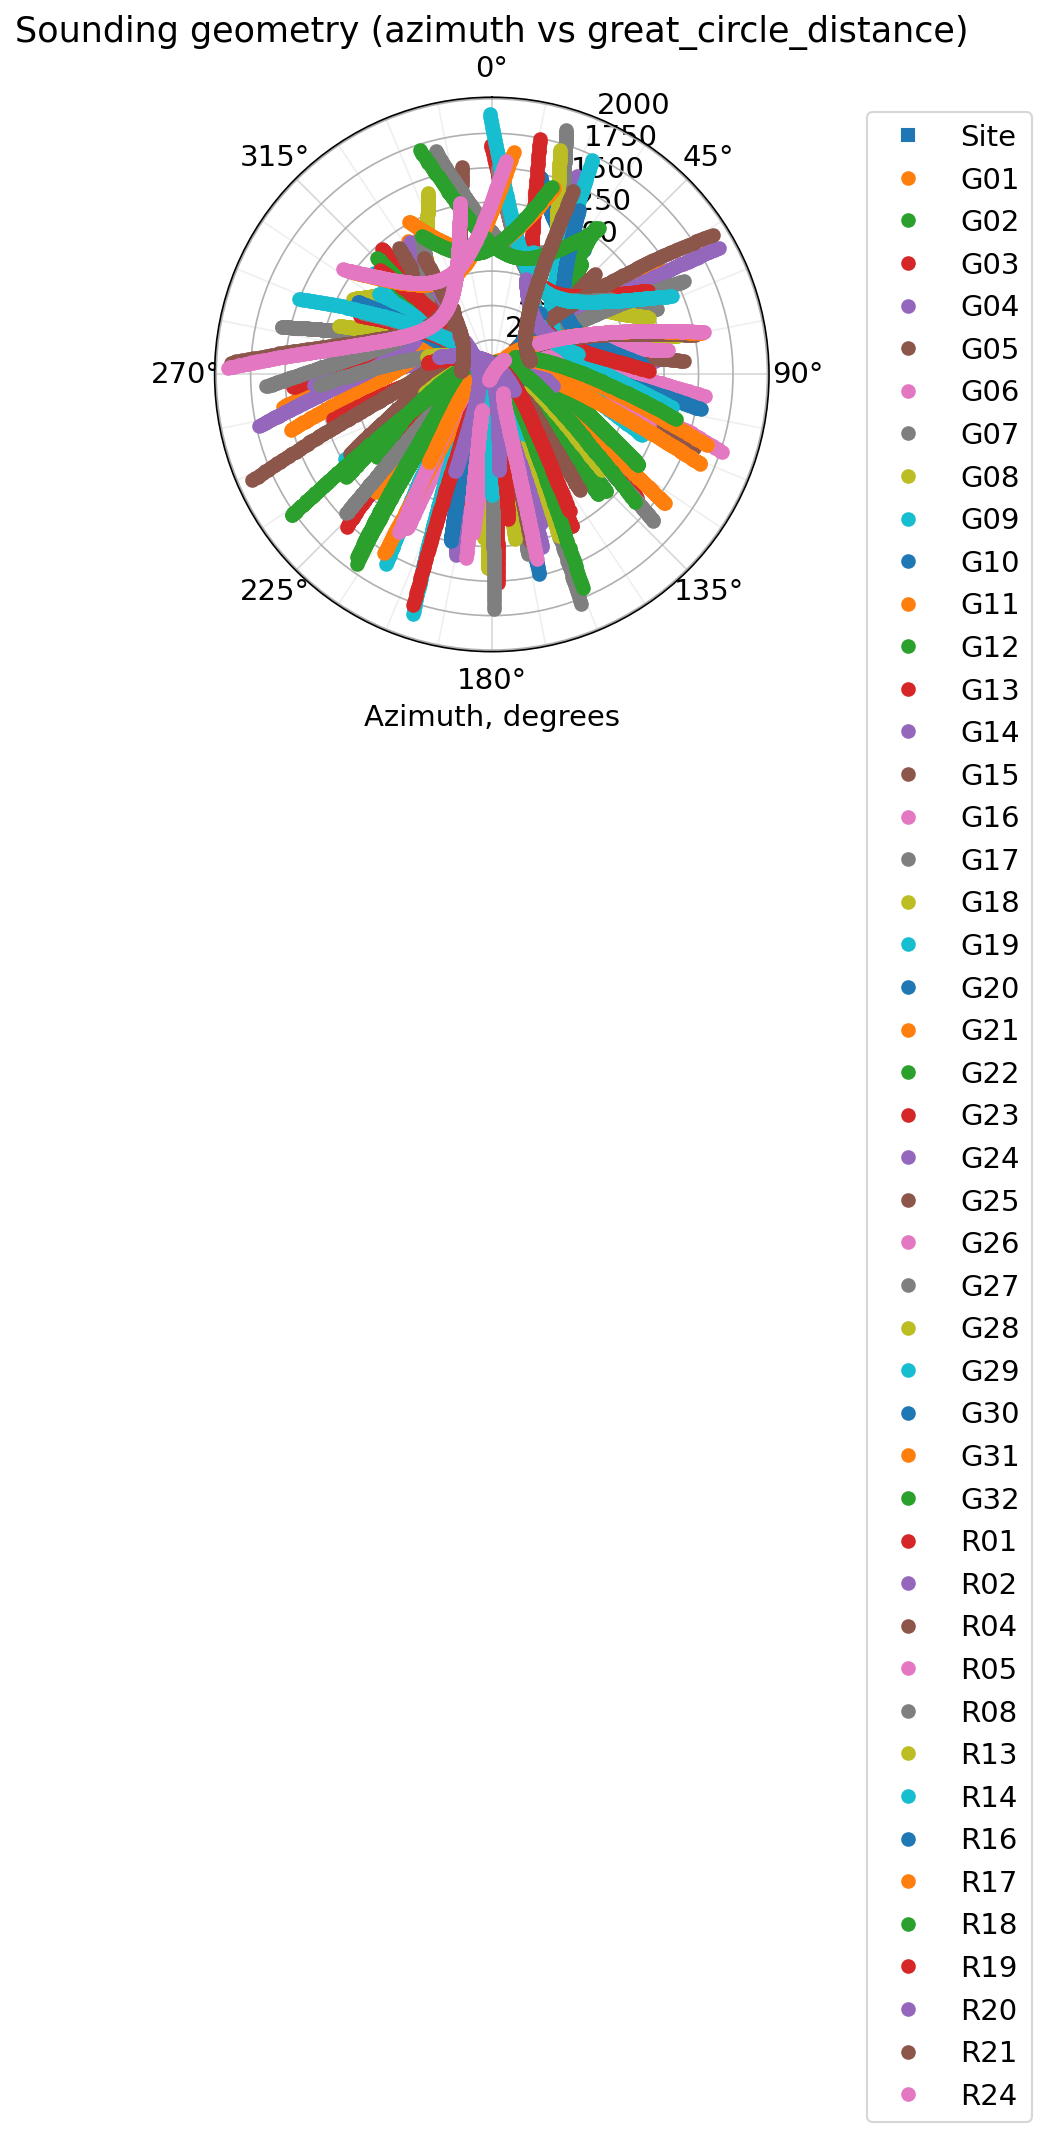

In [14]:
plotter = PlotManager([Plots.IPP_POLAR])
plot_data = {Plots.IPP_POLAR:(ipp_data, {})}
plotter.draw_plots(plot_data)